In [5]:
import sys
import numpy as np
import matplotlib.pyplot as plt

print(sys.executable)

/home/aviraljoshi/mini-logistic-regression/.venv/bin/python3


In [10]:
# Toy data: 3 tumours, 2 measurements each (radius, texture)
X = np.array([[2, 3],
              [1, 1],
              [4, 2]])
w = np.array([2, 1])   # one weight per measurement
b = -5                 # one shared bias

z = X @ w + b

print("X shape:", X.shape)
print("w shape:", w.shape)
print("z shape:", z.shape)
print("z:", z)

X shape: (3, 2)
w shape: (2,)
z shape: (3,)
z: [ 2 -2  5]


## The number `e` and `e^z`

- **`e ≈ 2.718`** is a mathematical constant, similar to π.
- **`e^z` is always positive**. It can become extremely small, but it never reaches `0` or becomes negative.
  - `e⁻¹⁰ ≈ 0.000045`
- **`e^z` grows extremely fast** as `z` increases.
  - `e¹⁰ ≈ 22,026`
  - `e¹⁰⁰ ≈ 2.69 × 10⁴³`

### Sigmoid function

The **sigmoid function** uses `e^z` to convert any number into a value between `0` and `1`:

`σ(z) = 1 / (1 + e^(-z))`

In NumPy:

```python
1 / (1 + np.exp(-z))

In [12]:
p = 1 / (1 + np.exp(-z))

print("z: ",z)
print("p: ",p)
print("p dtype: ", p.dtype)

z:  [ 2 -2  5]
p:  [0.88079708 0.11920292 0.99330715]
p dtype:  float64


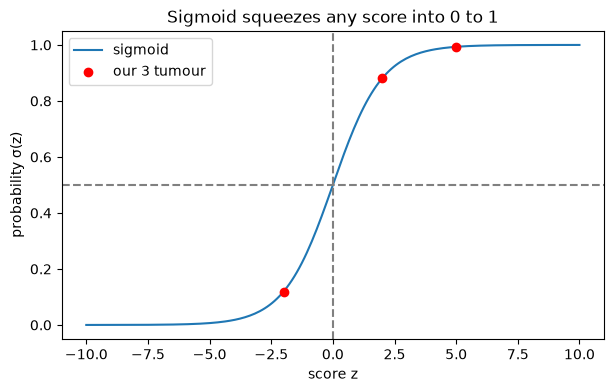

In [16]:
z_range = np.linspace(-10, 10, 200)
p_range = 1 / (1 + np.exp(-z_range))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(z_range, p_range, label="sigmoid")
ax.scatter(z, p, color="red", zorder=3, label="our 3 tumour")
ax.axhline(0.5, color="gray", linestyle= "--")
ax.axvline(0, color="gray", linestyle= "--")
ax.set_xlabel("Probalities")
ax.set_xlabel("score z")
ax.set_ylabel("probability σ(z)")
ax.set_title("Sigmoid squeezes any score into 0 to 1")
ax.legend()
plt.show()

In [17]:
threshold = 0.5

is_above = p >= threshold
y_pred = is_above.astype(int)

print("is_above:", is_above, is_above.dtype)
print("y_pred:  ", y_pred, y_pred.dtype)

is_above: [ True False  True] bool
y_pred:   [1 0 1] int64


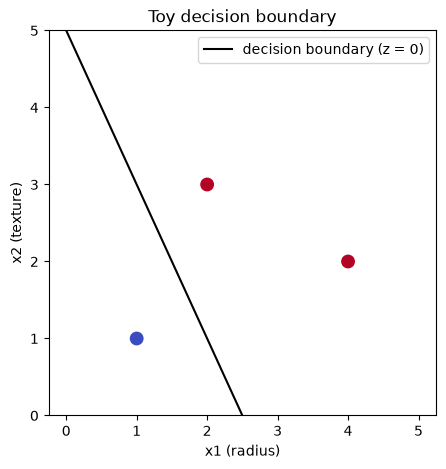

In [19]:
# toy boundary split our 3 tumours?
x1_line = np.linspace(0, 5, 50)
x2_line = -(w[0] * x1_line + b) / w[1]   # from w1*x1 + w2*x2 + b = 0

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(x1_line, x2_line, color="black", label="decision boundary (z = 0)")
ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="coolwarm", s=80, zorder=3)
ax.set_ylim(0, 5)
ax.set_xlabel("x1 (radius)")
ax.set_ylabel("x2 (texture)")
ax.set_title("Toy decision boundary")
ax.legend()
plt.show()

## Log-odds

**Log-odds** tells us how strongly the model favors one class over the other.

`log-odds = ln(p / (1 - p))`

For logistic regression:

`z = Xw + b`

and the **log-odds are exactly equal to `z`**.

So:

`z = Xw + b = log-odds`

### The chain works in both directions

**Forward:**

`z → sigmoid → p`

The model starts with `z` and converts it into a probability `p`.

**Backward:**

`p → odds → ln → z`

We can start with the probability, calculate the odds, take the natural logarithm, and get back to `z`.

> **Key idea:** In logistic regression, `z = Xw + b` is not just an intermediate calculation — it represents the **log-odds** of the predicted class.

In [20]:
odds = p / (1 - p)
log_odds = np.log(odds)

print("z:       ", z)
print("odds:    ", odds)
print("log_odds:", log_odds)
print("log_odds equals z?", np.allclose(log_odds, z))

z:        [ 2 -2  5]
odds:     [7.38905610e+00 1.35335283e-01 1.48413159e+02]
log_odds: [ 2. -2.  5.]
log_odds equals z? True
